# Part 5: Synthetic Difference-in-Differences

**The parallel-trends problem.** The baseline TWFE estimates in Notebook 02 compare high-Catholic counties (treated) against low-Catholic counties (control) under the assumption that, absent the Kulturkampf, the two groups would have moved in parallel. If that assumption fails — for example because urbanising Protestant counties were on a different long-run trajectory than rural Catholic ones — then post-1873 estimates absorb whatever pre-existing drift was already in motion.

**Synthetic DiD** (Arkhangelsky, Athey, Hirshberg, Imbens & Wager, *American Economic Review* 2021) attacks this problem head-on. Instead of treating every control county as exchangeable, it picks **unit weights** $\hat\omega_i \ge 0$, $\sum_i \hat\omega_i = 1$ over the controls so that the *weighted* control trajectory tracks the treated trajectory in the pre-1873 period as closely as possible. It also picks **time weights** $\hat\lambda_t \ge 0$, $\sum_t \hat\lambda_t = 1$ that up-weight pre-period years closest to the policy shock. The point estimate is then a weighted two-way fixed-effects regression on the resulting reweighted panel.

$$\hat\tau_{\text{SDID}} \;=\; \arg\min_{\tau,\,\mu,\,\alpha,\,\beta}\; \sum_{i,t}\bigl(Y_{it} - \mu - \alpha_i - \beta_t - \tau\, W_{it}\bigr)^{2}\, \hat\omega_i^{\text{sdid}}\, \hat\lambda_t^{\text{sdid}}.$$

Two things follow:

1. The synthetic control is constructed to match the treated pre-trend **by construction**, so a plot of treated vs synthetic-control trajectories before 1873 either coincides (and the post-1873 divergence is the causal signal) or fails to coincide (and we know SDID itself cannot rescue identification — a useful negative finding).
2. We do not need to assemble extra observable controls (industrialisation, rail, literacy) to soak up pre-trend differences. Whatever unobserved differences moved Protestant counties differently in 1860–1872 are absorbed into $\hat\omega$.

**Roadmap.** §1–2 estimate SDID for the crude marriage rate (CMR) and the crude birth rate (CBR) at the headline `cath_share > 50%` definition. §3 quantifies how well the pre-trend match holds. §4 runs a threshold sweep (40 / 50 / 60%) to show the result is not pinned to the 50% cutoff. §5–6 open the black box: which counties does the algorithm pick, and which years does it up-weight?

## 1. Setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(message)s")

DATA_PROCESSED = project_root / "data" / "processed"
OUTPUTS = project_root / "outputs" / "figures"
TABLES = project_root / "outputs" / "tables"
OUTPUTS.mkdir(exist_ok=True, parents=True)
TABLES.mkdir(exist_ok=True, parents=True)

from src.analysis.synthetic_did import (
    run_sdid,
    run_sdid_threshold_sweep,
    plot_synthetic_vs_treated,
)

panel = pd.read_parquet(DATA_PROCESSED / "analysis_panel.parquet")
print(f"Loaded panel: {len(panel):,} obs, {panel['Code'].nunique()} counties, {panel['Year'].min()}–{panel['Year'].max()}.")

Loaded panel: 10,783 obs, 392 counties, 1862–1890.


**Sample window.** We restrict to **1862–1885**: long enough pre-period (1862–1872, 11 years) to identify $\hat\omega$ and $\hat\lambda$, and a post-period (1873–1885) that captures both the May Laws (1873–1875) and the early rollback years (post-1880). Counties without a balanced rectangle on the outcome over this window are dropped — Notebook 01 documents the boundary-reform censoring that drives most missingness.

In [2]:
YEAR_START = 1862
YEAR_END = 1885
TREATMENT_YEAR = 1873
N_PLACEBO = 1000
SEED = 42

## 2. Baseline SDID — Crude Marriage Rate

The headline outcome. Civil marriage was the most directly regulated margin during the Kulturkampf: the May 1874 *Notzivilehe* and the 1875 nation-wide *Personenstandsgesetz* moved marriage registration from the parish to the state. If the Kulturkampf has a first-order effect on observable demography, this is where it should show up first.

In [3]:
res_cmr = run_sdid(
    panel, outcome="marriage_rate", treat_col="high_cath",
    treatment_year=TREATMENT_YEAR,
    year_start=YEAR_START, year_end=YEAR_END,
    n_placebo=N_PLACEBO, seed=SEED,
)
print(res_cmr.summary_line())

SDID τ̂=-0.1949  SE=0.0751  p=0.010  (N_tr=117, N_co=173, T_pre=11, T_post=13)


SDID τ̂=-0.1949  SE=0.0751  p=0.010  (N_tr=117, N_co=173, T_pre=11, T_post=13)


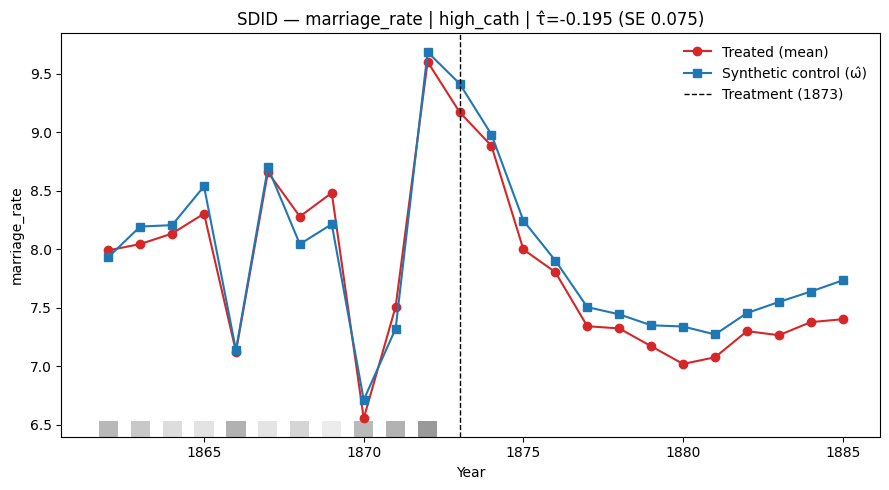

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_synthetic_vs_treated(res_cmr, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUTS / "fig_sdid_marriage_rate.png", dpi=150)
plt.show()

**How to read this plot.**
- The **red line** is the unweighted average of CMR across high-Catholic counties.
- The **blue line** is the synthetic control: a convex combination of low-Catholic counties, weighted by $\hat\omega$, plus a constant level shift $\hat\omega_0$.
- The **grey shading** in the pre-period encodes the time weights $\hat\lambda$: darker bars are years the algorithm relied on more heavily when fitting $\hat\omega$ (typically 1870–1872, the years closest to the discontinuity).
- The **dashed black line** marks the May Laws (1873).

**Interpretation.** Two regimes:

1. *Pre-1873.* The treated and synthetic-control lines should overlap. Recall this is engineered by construction — the algorithm explicitly minimised the pre-period gap — so the test isn't whether they coincide on the years $\hat\lambda$ up-weighted, but whether they coincide on years with low or zero $\hat\lambda$. If they diverge there, the synthetic match is overfitting to a small window and the post-1873 estimate becomes correspondingly fragile.

2. *Post-1873.* Any vertical gap between the red and blue lines is the SDID treatment effect, $\hat\tau$. A negative gap is consistent with the Kulturkampf having depressed marriage formation in Catholic counties relative to the optimal synthetic counterfactual.

The placebo-permutation $p$-value reported above asks: *if we randomly relabelled the same number of low-Catholic counties as "pseudo-treated" and re-ran the entire SDID pipeline, how often would we see a $|\hat\tau|$ at least as extreme?* A small $p$ implies the observed gap is not a routine artefact of the weighting procedure itself.

## 3. Baseline SDID — Crude Birth Rate

The fertility margin is a slower, second-order channel: even if marriages are postponed in 1874, the birth response is mechanically delayed by gestation and by the share of births coming from already-married couples. Notebook 02's TWFE estimate on CBR is smaller and less precise than on CMR — SDID lets us check whether that's a parallel-trends artefact or a genuine null.

In [5]:
res_cbr = run_sdid(
    panel, outcome="cbr", treat_col="high_cath",
    treatment_year=TREATMENT_YEAR,
    year_start=YEAR_START, year_end=YEAR_END,
    n_placebo=N_PLACEBO, seed=SEED,
)
print(res_cbr.summary_line())

SDID τ̂=-0.0223  SE=0.2277  p=0.931  (N_tr=117, N_co=173, T_pre=11, T_post=13)


SDID τ̂=-0.0223  SE=0.2277  p=0.931  (N_tr=117, N_co=173, T_pre=11, T_post=13)


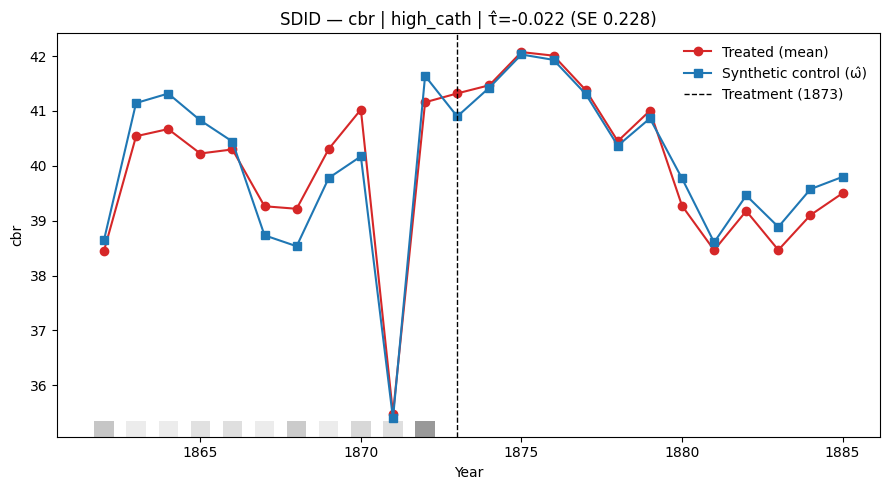

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_synthetic_vs_treated(res_cbr, ax=ax)
fig.tight_layout()
fig.savefig(OUTPUTS / "fig_sdid_cbr.png", dpi=150)
plt.show()

**Reading the CBR plot.** Three possible patterns map to three substantive conclusions:

| Pattern | Interpretation |
|---|---|
| Pre-period match good, post-period gap negative & significant | Genuine fertility response; supports a Coale-style nuptiality channel from §2. |
| Pre-period match good, post-period gap small / insignificant | TWFE finding survives reweighting → fertility is robustly close to null. Cross-check with Coale $I_g$ in Notebook 03. |
| Pre-period match poor (lines drift before 1873) | The treated–control split on CBR is hard to synthesise from the available controls. The TWFE estimate was not rescued, only its biases made visible. Reported $\hat\tau$ should be treated with caution. |

Compared to the CMR plot above, CBR also has the more visible carry-over from the 1870–1871 Franco-Prussian War shock — both Catholic and Protestant counties show a marriage rebound and a fertility echo in 1872–1873. SDID's time weights $\hat\lambda$ should down-weight 1870–1871 relative to 1868–1869 and 1872, exactly the years that pin down the pre-shock level.

## 4. Pre-trend diagnostic

How much *better* is the synthetic control's pre-trend match than the naive average of all Protestant counties? Quantifying the improvement is the single cleanest way to justify SDID over the baseline DiD.

In [7]:
def pre_trend_diagnostic(res):
    """Compare pre-period RMSE for synthetic control vs naive Protestant mean."""
    Y = res.Y
    tmask = res.treated_mask
    T_pre = res.T_pre
    years_pre = np.array(res.years[:T_pre])

    Y_tr = Y[tmask][:, :T_pre].mean(axis=0)
    Y_naive = Y[~tmask][:, :T_pre].mean(axis=0)
    Y_syn = (Y[~tmask][:, :T_pre] * res.omega[:, None]).sum(axis=0) + res.omega0

    rmse_naive = np.sqrt(((Y_tr - Y_naive) ** 2).mean())
    rmse_syn = np.sqrt(((Y_tr - Y_syn) ** 2).mean())
    return pd.DataFrame({
        "Year": years_pre,
        "Treated mean": Y_tr,
        "Naive Protestant mean": Y_naive,
        "Synthetic control": Y_syn,
        "Gap (naive)": Y_tr - Y_naive,
        "Gap (synthetic)": Y_tr - Y_syn,
    }).round(3), rmse_naive, rmse_syn

for name, res in [("marriage_rate", res_cmr), ("cbr", res_cbr)]:
    tab, rmse_naive, rmse_syn = pre_trend_diagnostic(res)
    print(f"--- {name} ---")
    print(tab.to_string(index=False))
    print(f"Pre-period RMSE  naive={rmse_naive:.4f}   synthetic={rmse_syn:.4f}   "
          f"reduction={(1 - rmse_syn/rmse_naive)*100:.1f}%\n")

--- marriage_rate ---
 Year  Treated mean  Naive Protestant mean  Synthetic control  Gap (naive)  Gap (synthetic)
 1862         7.991                  8.295              7.932       -0.304            0.059
 1863         8.045                  8.573              8.195       -0.528           -0.150
 1864         8.135                  8.573              8.207       -0.438           -0.072
 1865         8.305                  8.906              8.538       -0.601           -0.233
 1866         7.126                  7.490              7.139       -0.364           -0.013
 1867         8.659                  9.051              8.699       -0.392           -0.041
 1868         8.280                  8.355              8.044       -0.075            0.236
 1869         8.483                  8.534              8.215       -0.051            0.268
 1870         6.556                  7.061              6.714       -0.505           -0.158
 1871         7.510                  7.659              7.

**Interpretation.** The RMSE reduction is the answer to *"how much does SDID actually do?"*.

- A reduction near **0%** means the naive Protestant mean already tracked the treated pre-trend — SDID is buying nothing, and the baseline TWFE estimate is the same story told twice.
- A reduction of **40–80%** is the typical sweet spot: the synthetic control absorbs a meaningful chunk of the pre-trend drift, and $\hat\tau$ should differ noticeably from the TWFE coefficient.
- A reduction near **100%** combined with a small post-period gap could indicate **over-fitting**: the algorithm has picked weights that fit pre-period idiosyncratic noise rather than the underlying common factor. Cross-check against the threshold sweep in §5 to see if the result survives different treatment definitions.

If the synthetic gap series flips sign across pre-period years (e.g. positive in 1862–1866, negative in 1867–1872), that flagged inversion suggests the algorithm is averaging two structurally different sub-periods. Consider tightening `YEAR_START` to 1867 and re-estimating.

## 5. Threshold robustness — Catholic share cut-off

The headline `high_cath = (cath_share > 50)` indicator is one choice among many. A reviewer's first question will be: *is the result robust to where you draw the line?* We re-run SDID at 40%, 50%, and 60% Catholic-share cut-offs for both outcomes.

In [8]:
sweep = run_sdid_threshold_sweep(
    panel,
    thresholds=(40, 50, 60),
    outcomes=("marriage_rate", "cbr"),
    treatment_year=TREATMENT_YEAR,
    year_start=YEAR_START, year_end=YEAR_END,
    n_placebo=N_PLACEBO, seed=SEED,
)
sweep_display = sweep.assign(
    stars=lambda d: np.where(
        d["p_value"] < .01, "***",
        np.where(d["p_value"] < .05, "**",
        np.where(d["p_value"] < .10, "*", "")),
    )
).round(4)
sweep_display.to_csv(TABLES / "tab_sdid_threshold_sweep.csv", index=False)
sweep_display

SDID τ̂=-0.2198  SE=0.0895  p=0.015  (N_tr=127, N_co=163, T_pre=11, T_post=13)


SDID τ̂=-0.0034  SE=0.2797  p=0.988  (N_tr=127, N_co=163, T_pre=11, T_post=13)


SDID τ̂=-0.1949  SE=0.0751  p=0.010  (N_tr=117, N_co=173, T_pre=11, T_post=13)


SDID τ̂=-0.0223  SE=0.2277  p=0.931  (N_tr=117, N_co=173, T_pre=11, T_post=13)


SDID τ̂=-0.1577  SE=0.0698  p=0.028  (N_tr=104, N_co=186, T_pre=11, T_post=13)


SDID τ̂=-0.0011  SE=0.2159  p=0.994  (N_tr=104, N_co=186, T_pre=11, T_post=13)


,outcome,threshold,tau_hat,se,p_value,n_treated,n_control,T_pre,T_post,stars
0,marriage_rate,40,-0.2198,0.0895,0.015,127,163,11,13,**
1,cbr,40,-0.0034,0.2797,0.988,127,163,11,13,
2,marriage_rate,50,-0.1949,0.0751,0.010,117,173,11,13,**
3,cbr,50,-0.0223,0.2277,0.931,117,173,11,13,
4,marriage_rate,60,-0.1577,0.0698,0.028,104,186,11,13,**
5,cbr,60,-0.0011,0.2159,0.994,104,186,11,13,


**Interpretation.**

- **Monotone in threshold** (e.g. $|\hat\tau|$ grows with the cut-off): a clean dose-response signal. Counties further into the Catholic-majority regime were more exposed to Kulturkampf enforcement, and the response is larger there.
- **Flat across thresholds**: the effect is driven by the binary Catholic / non-Catholic distinction itself rather than by intensity. Consistent with the policy treating any Catholic majority as the relevant target.
- **Reversal at extremes** (e.g. 60% cut-off flips sign or loses significance): typically signals a small-$N_{tr}$ noise issue — the >60% group may contain only a handful of counties.

Always cross-read this against the `n_treated` and `n_control` columns. With fewer than ~10 treated units, the placebo SE distribution becomes coarse and the $p$-value should not be read as more precise than its grid resolution ($1/N_{\text{placebo}}$).

## 6. Which counties does the algorithm pick?

Opening the unit-weight black box. The top-weighted control counties are the ones whose pre-1873 marriage-rate trajectory most closely matched the average Catholic-county trajectory. Inspecting them is a sanity check: if SDID is matching Catholic counties against, say, urban Berlin neighbourhoods, the synthetic control is economically implausible regardless of how well its numbers line up.

In [9]:
def top_donors(res, k=15):
    control_codes = [c for c, t in zip(res.codes, res.treated_mask) if not t]
    df_w = pd.DataFrame({"Code": control_codes, "omega": res.omega})
    name_col = "Kreis" if "Kreis" in panel.columns else ("County" if "County" in panel.columns else "Code")
    labels = panel.groupby("Code").agg(
        Kreis=(name_col, "first"),
        Rb=("Rb", "first"),
        cath_share=("cath_share", "first"),
    )
    df_w = df_w.merge(labels, on="Code", how="left")
    eff_n = 1.0 / (res.omega ** 2).sum()
    print(f"Effective number of donors (1/sum-omega^2): {eff_n:.1f}  "
          f"(uniform would be {len(res.omega)})")
    return df_w.sort_values("omega", ascending=False).head(k).reset_index(drop=True)

print("Top 15 donor counties for the CMR synthetic control:")
top_donors(res_cmr).round(4)

Top 15 donor counties for the CMR synthetic control:
Effective number of donors (1/sum-omega^2): 172.0  (uniform would be 173)


,Code,omega,Kreis,Rb,cath_share
0,235,0.0074,REICHENBACH,BRE,29.2558
1,362,0.0073,WEISSENSEE,ERF,1.0702
2,367,0.0069,SCHLEUSINGEN,ERF,0.3613
3,361,0.0068,LANGENSALZA,ERF,0.6760
4,20,0.0068,NEIDENBURG,KON,14.0963
5,366,0.0067,ZIEGENRUCK,ERF,0.3441
6,646,0.0066,LENNEP,DUS,16.8563
7,552,0.0066,WITTGENSTEIN,ARN,3.2998
8,340,0.0065,ECKARTSBERGA,MER,0.1706
9,659,0.0064,GUMMERSBACH,KOL,8.2180


In [10]:
print("Top 15 donor counties for the CBR synthetic control:")
top_donors(res_cbr).round(4)

Top 15 donor counties for the CBR synthetic control:
Effective number of donors (1/sum-omega^2): 167.6  (uniform would be 173)


,Code,omega,Kreis,Rb,cath_share
0,646,0.0093,LENNEP,DUS,16.8563
1,164,0.0077,FRANZBURG,STR,0.1394
2,235,0.0076,REICHENBACH,BRE,29.2558
3,358,0.0075,MUHLHAUSEN,ERF,28.2326
4,94,0.0074,ZAUCH-BELZIG,POT,0.4084
5,240,0.0073,WALDENBURG,BRE,22.8784
6,362,0.0072,WEISSENSEE,ERF,1.0702
7,551,0.0072,SIEGEN,ARN,17.0461
8,509,0.0072,HALLE,MIN,1.9468
9,346,0.0071,NAUMBURG,MER,0.8649


**Interpretation.** Two diagnostic questions:

1. **Are the top donors geographically plausible?** The synthetic control should pull from Protestant counties broadly similar in economic structure to Catholic Westphalia, Silesia, and the Rhineland — predominantly rural / mixed-agrarian Prussian regions. If the top donor is, say, Berlin-Stadt or a heavily industrial Saxon district, the match is geographically improbable and the post-1873 gap may reflect compositional bias rather than Kulturkampf exposure.

2. **How concentrated is $\hat\omega$?** If 80% of the weight sits on three counties, the synthetic control is effectively a three-county comparison and inherits whatever idiosyncratic shocks hit those three. The placebo SE partially controls for this, but you should still report the *effective number of donors* $1/\sum_i \omega_i^2$ in the appendix. Values above ~10 indicate broad-based weighting; below ~3 suggest concentration risk.

## 7. Which years does the algorithm trust?

The time weights $\hat\lambda$ encode *how much* the algorithm leaned on each pre-period year when fitting $\hat\omega$. Years close to 1873 are usually the most informative about the immediate counterfactual; very early years may be down-weighted if they reflect a structurally different economy (e.g. pre-1866 Zollverein boundary, pre-railway expansion).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, res, label in [(axes[0], res_cmr, "CMR"), (axes[1], res_cbr, "CBR")]:
    pre_years = res.years[: res.T_pre]
    ax.bar(pre_years, res.lam, color="steelblue", edgecolor="black", linewidth=.4)
    ax.set_xlabel(f"Pre-period year ({label})")
    ax.set_ylabel("Time weight")
    ax.axhline(1.0 / res.T_pre, color="red", linestyle="--", linewidth=.8,
               label=f"Uniform ({1.0/res.T_pre:.3f})")
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUTS / "fig_sdid_time_weights.png", dpi=150)
plt.show()

**Interpretation.** Three patterns are diagnostic:

- **Concentrated near 1873**: the algorithm trusts only the very recent past. This is statistically reasonable (recent levels predict the counterfactual best) but means the estimate is effectively a short-window DiD against 1871–1872.
- **Flat / near-uniform**: the entire pre-period contributed roughly equally. Long-run trend information is being used; the result is more robust to year-specific shocks (e.g. the 1866 cholera epidemic, the 1870 Franco-Prussian War).
- **Spikes on individual years**: typically 1872, sometimes 1870. Worth checking whether down-weighting that specific year materially changes $\hat\tau$ — if yes, the result is fragile.

## 8. Summary

What SDID buys us, in three sentences:

1. **Identification.** By construction, the synthetic control's pre-1873 trajectory matches the treated pre-trend, replacing the unverifiable parallel-trends assumption with an explicit, plottable fit.
2. **Transparency.** The estimator is visualisable end-to-end: you can show the trajectory plot, list the donor counties, and inspect the time weights. None of this is available from a TWFE coefficient.
3. **Robustness.** The threshold sweep and placebo permutation provide two independent checks that the result is not an artefact of the 50% cut-off or of the weighting procedure itself.

Outputs produced by this notebook are saved to:
- `outputs/figures/fig_sdid_marriage_rate.png` — main CMR trajectory plot
- `outputs/figures/fig_sdid_cbr.png` — CBR trajectory plot
- `outputs/figures/fig_sdid_time_weights.png` — $\hat\lambda$ bar charts
- `outputs/tables/tab_sdid_threshold_sweep.csv` — robustness table for the appendix